# Machine Learning for CICY 4-Folds (Inception ResNet)

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import time
import gzip
import json
import gc
from IPython.display import Image
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from tensorflow import keras
from nn_tools.nn_models.models import *
from nn_tools.nn_models.callbacks import *

import warnings
warnings.filterwarnings('ignore', message='The objective has been evaluated at this point before.')

# set matplot
sns.set()
PREFIX = 'cicy4_'
SUFFIX = '_inception_resnet'

# set memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
        
# set random seed
RAND = 123
np.random.seed(RAND)
tf.random.set_seed(RAND)
#tf.compat.v1.set_random_seed(RAND)

In [2]:
proot = lambda s: os.path.join('.', s)
pdata = lambda s: os.path.join(proot('data'), s)
pimg  = lambda s: os.path.join(proot('img'), s)
ppred = lambda s: os.path.join(proot('pred'), s)
plogs = lambda s: os.path.join(proot('logs'), s)

os.makedirs(proot('data'), exist_ok=True)
os.makedirs(proot('img'), exist_ok=True)
os.makedirs(proot('pred'), exist_ok=True)
os.makedirs(proot('logs'), exist_ok=True)

## Download and Read the Dataset

In [3]:
data = keras.utils.get_file('cicy4_eng.json.gz',
                            'https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz',
                            cache_dir='.',
                            cache_subdir='data'
                           )

## Reading the Dataset

In [4]:
df = pd.read_json(pdata('cicy4_eng.json.gz'), orient='index')

In [5]:
# select only non product manifolds
df = df.loc[df['isprod'] == False]

# select only complete entries
df = df.dropna()

## Plots

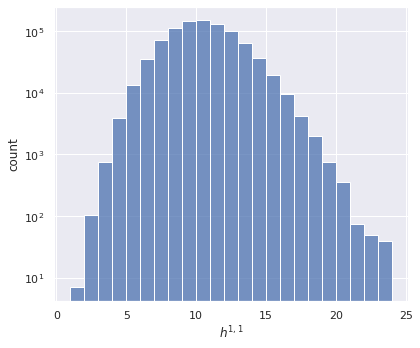

In [6]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=df,
             x='h11',
             stat='count',
             binwidth=1,
             ax=ax
            )
ax.set_xlabel('$h^{1,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

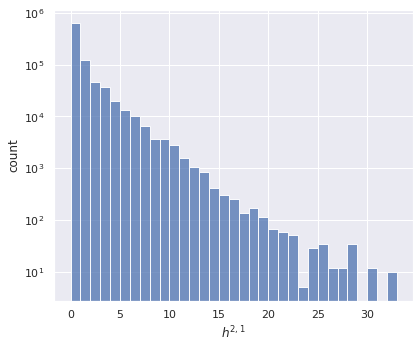

In [7]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=df,
             x='h21',
             stat='count',
             binwidth=1,
             ax=ax
            )
ax.set_xlabel('$h^{2,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

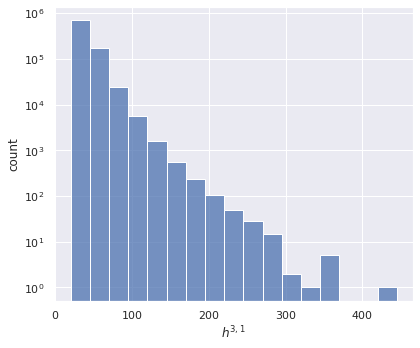

In [8]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=df,
             x='h31',
             stat='count',
             binwidth=25,
             ax=ax
            )
ax.set_xlabel('$h^{3,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

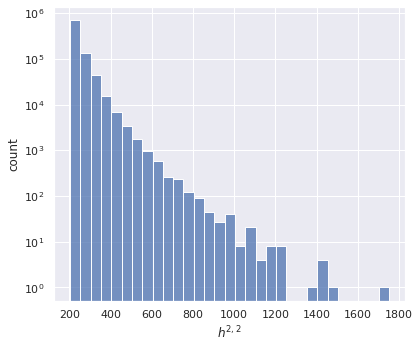

In [9]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=df,
             x='h22',
             stat='count',
             binwidth=50,
             ax=ax
            )
ax.set_xlabel('$h^{2,2}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Correlations

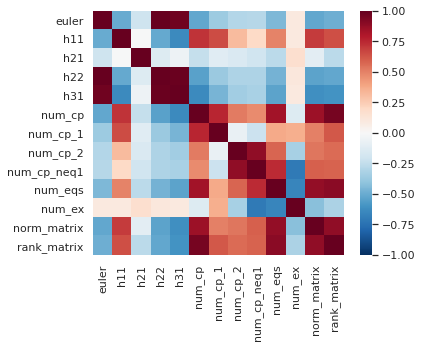

In [10]:
corr = df[['euler',
           'h11',
           'h21',
           'h22',
           'h31',
           'num_cp',
           'num_cp_1',
           'num_cp_2',
           'num_cp_neq1',
           'num_eqs',
           'num_ex',
           'norm_matrix',
           'rank_matrix'
          ]
         ].corr()

_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.heatmap(corr,
            vmin=-1.0,
            vmax=1.0,
            cmap='RdBu_r',
            center=0.0
           )

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'correlations' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Distributions

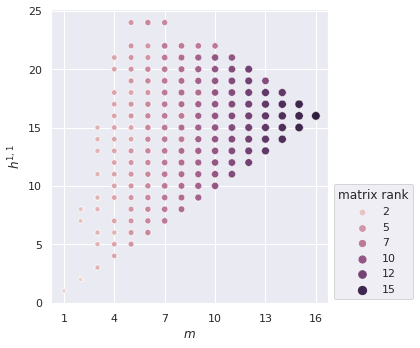

In [11]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h11',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('$m$')
ax.set_ylabel('$h^{1,1}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(title='matrix rank', bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

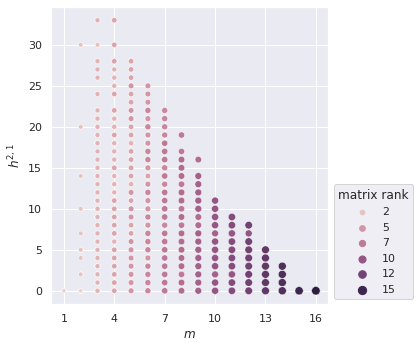

In [12]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h21',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('$m$')
ax.set_ylabel('$h^{2,1}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(title='matrix rank', bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

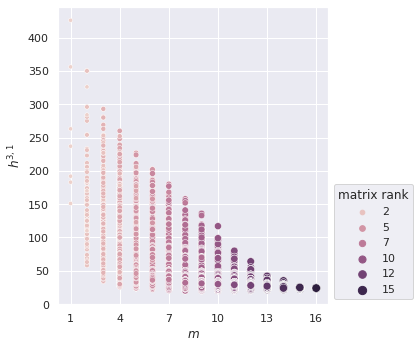

In [13]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h31',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('$m$')
ax.set_ylabel('$h^{3,1}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(title='matrix rank', bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

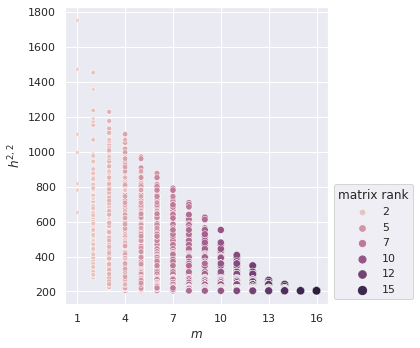

In [14]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h22',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('$m$')
ax.set_ylabel('$h^{2,2}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(title='matrix rank', bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

## Train, Validation, Test Splits

In [15]:
# get the max shape of the matrix
shape = df['size'].max()

# get the max length
dim_cp_shape  = df['dim_cp'].apply(np.shape).max()
deg_eqs_shape = df['deg_eqs'].apply(np.shape).max()

In [16]:
df_train, df_test = train_test_split(df, test_size=0.02, shuffle=True, random_state=RAND)
df_val, df_test   = train_test_split(df_test, test_size=0.5, shuffle=True, random_state=RAND)

print(f'Training set:   {df_train.shape[0]:d} samples (fraction: {df_train.shape[0] / df.shape[0]:.3f})')
print(f'Validation set: {df_val.shape[0]:d} samples (fraction: {df_val.shape[0] / df.shape[0]:.3f})')
print(f'Test set:       {df_test.shape[0]:d} samples (fraction: {df_test.shape[0] / df.shape[0]:.3f})')

Training set:   887570 samples (fraction: 0.980)
Validation set: 9057 samples (fraction: 0.010)
Test set:       9057 samples (fraction: 0.010)


## Remove Outliers from Train Set

In [17]:
#low_quantile  = 0.05
#high_quantile = 0.95
#
#quantile = df_train.quantile(q=[low_quantile, high_quantile])
#quantile

In [18]:
#df_train = df_train.loc[(df_train['h11'] >= quantile['h11'].loc[low_quantile]) & (df_train['h11'] <= quantile['h11'].loc[high_quantile])
#                        & (df_train['h21'] >= quantile['h21'].loc[low_quantile]) & (df_train['h21'] <= quantile['h21'].loc[high_quantile])
#                        & (df_train['h31'] >= quantile['h31'].loc[low_quantile]) & (df_train['h31'] <= quantile['h31'].loc[high_quantile])
#                        & (df_train['h22'] >= quantile['h22'].loc[low_quantile]) & (df_train['h22'] <= quantile['h22'].loc[high_quantile])
#                       ]
#df_train.info()

## Add Permutations

In [19]:
## number of permutation runs to perform
#n_runs = 2
#
## add permutations
#for _ in range(n_runs):
#    df_new           = df_train.copy()
#    df_new['matrix'] = df_new['matrix'].apply(lambda M: np.transpose(np.random.permutation(np.transpose(np.random.permutation(M)))))
#    df_train         = df_train.append(df_new, ignore_index=True)
#    del df_new

In [20]:
#print(f'New training set size: {df_train.shape}')

In [21]:
#df_train.info()

## Save Sets to File

In [22]:
df_train.to_csv(pdata(PREFIX + 'train_set' + SUFFIX + '.csv.gz'), index=False)
df_val.to_csv(pdata(PREFIX + 'val_set' + SUFFIX + '.csv.gz'), index=False)
df_test.to_csv(pdata(PREFIX + 'test_set' + SUFFIX + '.csv.gz'), index=False)

## Building the Configuration Matrices (Sparse to Dense)

In [23]:
# get the offset and pad the matrix
offset = lambda s: [(0, shape[i] - np.shape(s)[i]) for i in range(len(shape))]
df_train['matrix'] = df_train['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))
df_val['matrix']   = df_val['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))
df_test['matrix']  = df_test['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))

<ipython-input-23-9f0c6ebceeb4>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['matrix'] = df_train['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))


## Building the Vector Features (Sparse to Dense)

In [24]:
## get the offset and pad
#offset_dim_cp = lambda s: (0, dim_cp_shape[0] - np.shape(s)[0])
#df_train['dim_cp']  = df_train['dim_cp'].apply(lambda s: np.pad(s, offset_dim_cp(s), mode='constant'))
#df_val['dim_cp']    = df_val['dim_cp'].apply(lambda s: np.pad(s, offset_dim_cp(s), mode='constant'))
#df_test['dim_cp']   = df_test['dim_cp'].apply(lambda s: np.pad(s, offset_dim_cp(s), mode='constant'))

#offset_deg_eqs = lambda s: (0, deg_eqs_shape[0] - np.shape(s)[0])
#df_train['deg_eqs']   = df_train['deg_eqs'].apply(lambda s: np.pad(s, offset_deg_eqs(s), mode='constant'))
#df_val['deg_eqs']     = df_val['deg_eqs'].apply(lambda s: np.pad(s, offset_deg_eqs(s), mode='constant'))
#df_test['deg_eqs']    = df_test['deg_eqs'].apply(lambda s: np.pad(s, offset_deg_eqs(s), mode='constant'))

## Rescale the Matrices

In [25]:
scale = df_train['matrix'].apply(np.max).max()

In [26]:
df_train['matrix'] = df_train['matrix'] / scale
df_val['matrix']   = df_val['matrix'] / scale
df_test['matrix']  = df_test['matrix'] / scale

<ipython-input-26-96f5e4928d09>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['matrix'] = df_train['matrix'] / scale


## Reshape Layers for CNN

In [27]:
reshape = tuple(shape + [1])

In [28]:
df_train['matrix'] = df_train['matrix'].apply(lambda x: np.reshape(x, reshape))
df_val['matrix']   = df_val['matrix'].apply(lambda x: np.reshape(x, reshape))
df_test['matrix']  = df_test['matrix'].apply(lambda x: np.reshape(x, reshape))

<ipython-input-28-65825c2fed84>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['matrix'] = df_train['matrix'].apply(lambda x: np.reshape(x, reshape))


## Create Dataset Generators

In [29]:
train_features = {'matrix': np.array([df_train['matrix'].iloc[n] for n in range(df_train.shape[0])]),
                  #'scalars': np.array([df_train[['num_cp', 'num_cp_1', 'num_cp_2', 'num_cp_neq1', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].iloc[n] for n in range(df_train.shape[0])]),
                  #'dim_cp': np.array([df_train['dim_cp'].iloc[n] for n in range(df_train.shape[0])]),
                  #'deg_eqs': np.array([df_train['deg_eqs'].iloc[n] for n in range(df_train.shape[0])])
                 }
val_features = {'matrix': np.array([df_val['matrix'].iloc[n] for n in range(df_val.shape[0])]),
                #'scalars': np.array([df_val[['num_cp', 'num_cp_1', 'num_cp_2', 'num_cp_neq1', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].iloc[n] for n in range(df_val.shape[0])]),
                #'dim_cp': np.array([df_val['dim_cp'].iloc[n] for n in range(df_val.shape[0])]),
                #'deg_eqs': np.array([df_val['deg_eqs'].iloc[n] for n in range(df_val.shape[0])])
               }
test_features = {'matrix': np.array([df_test['matrix'].iloc[n] for n in range(df_test.shape[0])]),
                 #'scalars': np.array([df_test[['num_cp', 'num_cp_1', 'num_cp_2', 'num_cp_neq1', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].iloc[n] for n in range(df_test.shape[0])]),
                 #'dim_cp': np.array([df_test['dim_cp'].iloc[n] for n in range(df_test.shape[0])]),
                 #'deg_eqs': np.array([df_test['deg_eqs'].iloc[n] for n in range(df_test.shape[0])])
                }

In [30]:
#scalars_shape = train_features['scalars'][0].shape

In [31]:
train_labels = {'h11': np.array(df_train['h11'].values.astype(np.int)),
                'h21': np.array(df_train['h21'].values.astype(np.int)),
                'h31': np.array(df_train['h31'].values.astype(np.int)),
                'h22': np.array(df_train['h22'].values.astype(np.int)),
               }
val_labels = {'h11': np.array(df_val['h11'].values.astype(np.int)),
              'h21': np.array(df_val['h21'].values.astype(np.int)),
              'h31': np.array(df_val['h31'].values.astype(np.int)),
              'h22': np.array(df_val['h22'].values.astype(np.int)),
             }
test_labels = {'h11': np.array(df_test['h11'].values.astype(np.int)),
               'h21': np.array(df_test['h21'].values.astype(np.int)),
               'h31': np.array(df_test['h31'].values.astype(np.int)),
               'h22': np.array(df_test['h22'].values.astype(np.int)),
              }

## Model Building

### Inception Network

In [32]:
matrix = nn_inception(input_shape=reshape,
                      name='matrix',
                      learning_rate=1.0e-3,
                      conv_1b1=True,
                      conv_layers=[128, 128, 64, 32],
                      conv_alpha=0.0,
                      conv_class=(6,6),
                      conv_single=True,
                      conv_red=32,
                      feat_map=32,
                      recurrent=True,
                      fc_layers=[100],
                      fc_alpha=0.0,
                      dropout=0.25,
                      full_dropout=0.05,
                      batchnorm=0.99,
                      last_relu=True,
                      loss_weights=[0.15, 0.20, 0.30, 0.35],
                      l1_reg=1.0e-3,
                      l2_reg=1.0e-3,
                      output_layers=True
                      #output_layers=False
                     )

matrix.summary()

Model: "matrix"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
matrix_convB1b1_0 (Conv2D)      (None, 16, 20, 128)  256         matrix[0][0]                     
__________________________________________________________________________________________________
matrix_actB1b1_0 (LeakyReLU)    (None, 16, 20, 128)  0           matrix_convB1b1_0[0][0]          
__________________________________________________________________________________________________
matrix_convBa_0 (Conv2D)        (None, 16, 20, 128)  49280       matrix_actB1b1_0[0][0]           
_____________________________________________________________________________________________

In [33]:
# TensorFlow v1
#keras.utils.plot_model(matrix,
#                       to_file=pimg(PREFIX + 'matrix_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

In [34]:
# TensorFlow v2
matrix_graph = keras.utils.model_to_dot(matrix, show_shapes=True, dpi=150)
matrix_graph.write_pdf(pimg(PREFIX + 'matrix_graph' + SUFFIX + '.pdf'))
Image(matrix_graph.create_png(), width=480)

### Dense Network

In [35]:
#scalars = nn_dense(input_shape=scalars_shape,
#                   name='scalars',
#                   learning_rate=1.0e-3,
#                   recurrent=False,
#                   fc_layers=[10, 10, 5],
#                   fc_alpha=0.0,
#                   dropout=0.1,
#                   batchnorm=0.99,
#                   last_relu=True,
#                   loss_weights=[0.25, 0.25, 0.25, 0.25],
#                   l1_reg=1.0e-5,
#                   l2_reg=1.0e-5,
#                   output_layers=True
#                   #output_layers=False
#                  )
#
#scalars.summary()

In [36]:
# TensorFlow v1
#keras.utils.plot_model(scalars,
#                       to_file=pimg(PREFIX + 'scalars_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

In [37]:
# TensorFlow v2
#scalars_graph = keras.utils.model_to_dot(scalars, show_shapes=True, dpi=150)
#scalars_graph.write_pdf(pimg(PREFIX + 'scalars_graph' + SUFFIX + '.pdf'))
#Image(scalars_graph.create_png(), width=480)

In [38]:
#dim_cp = nn_dense(input_shape=dim_cp_shape,
#                  name='dim_cp',
#                  learning_rate=1.0e-3,
#                  recurrent=False,
#                  fc_layers=[20, 10, 5],
#                  fc_alpha=0.0,
#                  dropout=0.1,
#                  batchnorm=0.99,
#                  last_relu=True,
#                  loss_weights=[0.25, 0.25, 0.25, 0.25],
#                  l1_reg=1.0e-5,
#                  l2_reg=1.0e-5,
#                  output_layers=True
#                  #output_layers=False
#                 )
#
#dim_cp.summary()

In [39]:
# TensorFlow v1
#keras.utils.plot_model(dim_cp,
#                       to_file=pimg(PREFIX + 'dim_cp_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

In [40]:
# TensorFlow v2
#dim_cp_graph = keras.utils.model_to_dot(dim_cp, show_shapes=True, dpi=150)
#dim_cp_graph.write_pdf(pimg(PREFIX + 'dim_cp_graph' + SUFFIX + '.pdf'))
#Image(dim_cp_graph.create_png(), width=480)

In [41]:
#deg_eqs = nn_dense(input_shape=deg_eqs_shape,
#                   name='deg_eqs',
#                   learning_rate=1.0e-3,
#                   recurrent=False,
#                   fc_layers=[20, 10, 5],
#                   fc_alpha=0.0,
#                   dropout=0.1,
#                   batchnorm=0.99,
#                   last_relu=True,
#                   loss_weights=[0.25, 0.25, 0.25, 0.25],
#                   l1_reg=1.0e-5,
#                   l2_reg=1.0e-5,
#                   output_layers=True
#                   #output_layers=False
#                  )
#
#deg_eqs.summary()

In [42]:
# TensorFlow v1
#keras.utils.plot_model(deg_eqs,
#                       to_file=pimg(PREFIX + 'deg_eqs_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

In [43]:
# TensorFlow v2
#deg_eqs_graph = keras.utils.model_to_dot(deg_eqs, show_shapes=True, dpi=150)
#deg_eqs_graph.write_pdf(pimg(PREFIX + 'deg_eqs_graph' + SUFFIX + '.pdf'))
#Image(deg_eqs_graph.create_png(), width=480)

### Full Model

In [44]:
#full_model = nn_full([matrix, scalars, dim_cp, deg_eqs],
#                     name='full_model',
#                     learning_rate=1.0e-3,
#                     last_relu=True,
#                     fc_layers=[20],
#                     fc_alpha=0.0,
#                     batchnorm=0.99,
#                     dropout=0.0,
#                     loss_weights=[0.25, 0.25, 0.25, 0.25],
#                     l1_reg=0.0,
#                     l2_reg=0.0
#                    )
#full_model.summary()

In [45]:
# TensorFlow v1
#keras.utils.plot_model(full_model,
#                       to_file=pimg(PREFIX + 'full_model_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

In [46]:
# TensorFlow v2
#full_model_graph = keras.utils.model_to_dot(full_model, show_shapes=True, dpi=150)
#full_model_graph.write_pdf(pimg(PREFIX + 'full_model_graph' + SUFFIX + '.pdf'))
#Image(full_model_graph.create_png(), width=480)

## Training the Model

In [47]:
epochs   = 40
interval = int(epochs / 10) if epochs > 10 else 1

In [48]:
batch_size = 64

In [49]:
full_model = matrix
full_model_hst = full_model.fit(x=train_features,
                                y=train_labels,
                                batch_size=batch_size,
                                epochs=epochs,
                                verbose=0,
                                callbacks=[keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'inception' + SUFFIX + '.h5'),
                                                                           monitor='val_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h11_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h11_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h21_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h21_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h31_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h31_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h22_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h22_loss',
                                                                           save_best_only=True
                                                                          ),
                                           #keras.callbacks.EarlyStopping(patience=int(epochs/2),
                                           #                              restore_best_weights=True
                                           #                             ),
                                           keras.callbacks.ReduceLROnPlateau(factor=0.1,
                                                                             patience=int(epochs/3),
                                                                             min_lr=1.0e-6
                                                                            ),
                                           keras.callbacks.TensorBoard(log_dir=proot('logs'),
                                                                       histogram_freq=interval,
                                                                       write_graph=True,
                                                                       write_images=True,
                                                                       update_freq='epoch',
                                                                       profile_batch=2,
                                                                       embeddings_freq=interval,
                                                                       embeddings_metadata=None
                                                                      ),
                                           PrintCheckpoint(interval)
                                          ],
                                validation_data=(val_features, val_labels)
                               )

Training has started. Callouts will be printed every 4 epochs.

Training epoch 1. Started on 20/09/2020 at 19:07:06.



    Average epoch training time: 1737.474 seconds
    loss = 1113.132
    h11_loss = 7.302
    h21_loss = 3.298
    h22_loss = 3407.822
    h31_loss = 101.740
    h11_mean_squared_error = 7.302
    h11_mean_absolute_error = 1.743
    h21_mean_squared_error = 3.298
    h21_mean_absolute_error = 1.009
    h22_mean_squared_error = 3407.822
    h22_mean_absolute_error = 26.610
    h31_mean_squared_error = 101.740
    h31_mean_absolute_error = 5.135
    val_loss = 123.305
    val_h11_loss = 3.203
    val_h21_loss = 3.255
    val_h22_loss = 274.468
    val_h31_loss = 18.726
    val_h11_mean_squared_error = 3.203
    val_h11_mean_absolute_error = 1.320
    val_h21_mean_squared_error = 3.255
    val_h21_mean_absolute_error = 0.883
    val_h22_mean_squared_error = 274.468
    val_h22_mean_absolute_error = 13.073
    val_h31_mean_squared_error = 18.726
    val_h31_mean_absolute_error = 3.581
    lr = 0.001


Training epoch 4. Started on 20/09/2020 at 20:23:53.



    Average epoch training time: 1585.965 seconds
    loss = 77.372
    h11_loss = 2.992
    h21_loss = 2.912
    h22_loss = 182.236
    h31_loss = 13.497
    h11_mean_squared_error = 2.992
    h11_mean_absolute_error = 1.307
    h21_mean_squared_error = 2.912
    h21_mean_absolute_error = 0.884
    h22_mean_squared_error = 182.236
    h22_mean_absolute_error = 9.744
    h31_mean_squared_error = 13.497
    h31_mean_absolute_error = 2.691
    val_loss = 104.258
    val_h11_loss = 3.033
    val_h21_loss = 3.406
    val_h22_loss = 262.384
    val_h31_loss = 22.781
    val_h11_mean_squared_error = 3.033
    val_h11_mean_absolute_error = 1.393
    val_h21_mean_squared_error = 3.406
    val_h21_mean_absolute_error = 0.762
    val_h22_mean_squared_error = 262.384
    val_h22_mean_absolute_error = 11.173
    val_h31_mean_squared_error = 22.781
    val_h31_mean_absolute_error = 3.319
    lr = 0.001


Training epoch 8. Started on 20/09/2020 at 21:59:29.



...

Training epoch 28. Started on 21/09/2020 at 05:57:21.



    Average epoch training time: 1471.488 seconds
    loss = 50.640
    h11_loss = 1.715
    h21_loss = 1.958
    h22_loss = 127.316
    h31_loss = 9.177
    h11_mean_squared_error = 1.715
    h11_mean_absolute_error = 0.935
    h21_mean_squared_error = 1.958
    h21_mean_absolute_error = 0.683
    h22_mean_squared_error = 127.316
    h22_mean_absolute_error = 8.434
    h31_mean_squared_error = 9.177
    h31_mean_absolute_error = 2.258
    val_loss = 31.805
    val_h11_loss = 0.837
    val_h21_loss = 1.607
    val_h22_loss = 69.515
    val_h31_loss = 5.660
    val_h11_mean_squared_error = 0.837
    val_h11_mean_absolute_error = 0.651
    val_h21_mean_squared_error = 1.607
    val_h21_mean_absolute_error = 0.617
    val_h22_mean_squared_error = 69.515
    val_h22_mean_absolute_error = 5.243
    val_h31_mean_squared_error = 5.660
    val_h31_mean_absolute_error = 1.633
    lr = 0.000


Training epoch 32. Started on 21/09/2020 at 07:32:56.



    Average epoch training time: 1467.170 seconds
    loss = 49.332
    h11_loss = 1.704
    h21_loss = 1.940
    h22_loss = 125.105
    h31_loss = 9.051
    h11_mean_squared_error = 1.704
    h11_mean_absolute_error = 0.932
    h21_mean_squared_error = 1.940
    h21_mean_absolute_error = 0.679
    h22_mean_squared_error = 125.105
    h22_mean_absolute_error = 8.412
    h31_mean_squared_error = 9.051
    h31_mean_absolute_error = 2.254
    val_loss = 48.887
    val_h11_loss = 0.730
    val_h21_loss = 1.404
    val_h22_loss = 124.857
    val_h31_loss = 8.947
    val_h11_mean_squared_error = 0.730
    val_h11_mean_absolute_error = 0.616
    val_h21_mean_squared_error = 1.404
    val_h21_mean_absolute_error = 0.606
    val_h22_mean_squared_error = 124.857
    val_h22_mean_absolute_error = 7.118
    val_h31_mean_squared_error = 8.947
    val_h31_mean_absolute_error = 1.978
    lr = 0.000


Training epoch 36. Started on 21/09/2020 at 09:08:31.



In [ ]:
full_model     = keras.models.load_model(pdata(PREFIX + 'inception' + SUFFIX + '.h5'))
full_h11_model = keras.models.load_model(pdata(PREFIX + 'h11_inception' + SUFFIX + '.h5'))
full_h21_model = keras.models.load_model(pdata(PREFIX + 'h21_inception' + SUFFIX + '.h5'))
full_h31_model = keras.models.load_model(pdata(PREFIX + 'h31_inception' + SUFFIX + '.h5'))
full_h22_model = keras.models.load_model(pdata(PREFIX + 'h22_inception' + SUFFIX + '.h5'))

In [ ]:
history = pd.DataFrame(full_model_hst.history)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['loss', 'val_loss']],
             palette=['tab:blue', 'tab:red'],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(['training', 'validation'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'loss_functions' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['val_h11_loss', 'val_h21_loss', 'val_h31_loss', 'val_h22_loss']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('validation loss')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(['$h^{1,1}$', '$h^{2,1}$', '$h^{3,1}$', '$h^{2,2}$'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'val_loss_functions' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['lr']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('learning rate')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'learning_rate' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Full Model

In [ ]:
_ = full_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

In [ ]:
train_predictions = full_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '.csv.gz'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=50,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=50,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=50,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{1,1}$ Model

In [ ]:
_ = full_h11_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

In [ ]:
train_predictions = full_h11_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h11_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h11_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h11_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h11_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h11_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h11_model.csv.gz'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{2,1}$ Model

In [ ]:
_ = full_h21_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

In [ ]:
train_predictions = full_h21_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h21_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h21_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h21_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h21_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h21_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h21_model.csv.gz'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{3,1}$ Model

In [ ]:
_ = full_h31_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

In [ ]:
train_predictions = full_h31_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h31_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h31_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h31_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h31_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h31_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h31_model.csv.gz'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{2,2}$ Model

In [ ]:
_ = full_h22_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

In [ ]:
train_predictions = full_h22_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h22_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h22_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h22_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h22_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h22_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [ ]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h22_model.csv.gz'))
metrics

In [ ]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)